In [1]:
# 라이브러리 기본 참조
from hossam import load_data
from pandas import DataFrame, melt
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
import numpy as np
# 선형회귀를 위한 참조
import statsmodels.api as sm
from statsmodels.formula.api import ols
# 결과 검정을 위한 참조
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import zscore, probplot, shapiro, anderson
from statsmodels.stats.api import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
# VIF값을 계산하기 위한 참조
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns

In [22]:
from hossam import util, prep, analysis
from hossam import plot as hs_plot

In [3]:
my_dpi = 200 # 이미지 선명도(100~300)
fpath = "./NotoSansKR-Regular.ttf" # 한글을 지원하는 폰트 파일의 경로
fm.fontManager.addfont(fpath) # 폰트의 글꼴을 시스템에 등록함
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트 이름 추출
plt.rcParams['font.family'] = fname # 그래프에 한글 폰트 적용
plt.rcParams['font.size'] = 6 # 기본 폰트 크기
plt.rcParams['axes.unicode_minus'] = False # 그래프에 마이너스 깨짐 방지

In [4]:
origin = load_data("insurance")
origin

[data] https://data.hossam.kr/data/kaggle/insurance.xlsx
[desc] 개인의 나이·성별·BMI·흡연 여부·거주 지역 등 기본 건강·인구학적 정보를 바탕으로 의료보험 청구 비용(charges)을 예측하도록 구성된, 선형회귀와 머신러닝 실습에 널리 사용되는 대표적인 보험 비용 데이터셋 (출처: https://www.kaggle.com/datasets/mirichoi0218/insurance)

변수명    의미(설명)
--------  ---------------------------------------------------------------
age       가입자의 나이(세).
sex       성별 (male, female).
bmi       체질량 지수(Body Mass Index).
children  부양 자녀 수(보험 내 자녀 수).
smoker    흡연 여부 (yes / no).
region    미국 내 거주 지역 (northeast, northwest, southeast, southwest).
charges   의료보험 청구 비용(달러). 예측해야 하는 타깃 변수.



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


📝미션 1. “이 데이터는 믿을 만할까?”결측·이상치·편향을 점검하고,<br>
처리 기준을 제시한다.charges가 음수이거나 극단값인지, age/bmi 등의 범위가 현실적인지 확인한다.<br>
범주형 변수(sex, smoker, region)가 몇 개의 범주로 구성되어 있고,<br>
특정 범주에 데이터가 지나치게 몰려 있지는않은지 확인한다.전처리 전·후가 어떻게 달라졌는지 한눈에 비교하는 표나 요약을 만든다.<br>
단위·해석 주의: charges는 USD입니다. 
현실적인 의료비 수준인지 평가하세요

In [5]:
n_rows, n_cols = origin.shape
print(f"총 행 수: {n_rows}")
print(f"총 열 수: {n_cols}")

total_nan = origin.isna().sum().sum()
print(f"총 NAN수:{total_nan}")

총 행 수: 1338
총 열 수: 7
총 NAN수:0


범주형 변수 범주수

In [6]:
origin['sex'].value_counts()
print(f"")

In [7]:
origin['region'].value_counts()


region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [8]:
s_count = origin['smoker'].value_counts(normalize=True)
print(f"일반적으로 smoker는 20% 내외\n40% 이상이면 표본 편향 의심")
s_count

일반적으로 smoker는 20% 내외
40% 이상이면 표본 편향 의심


smoker
no     0.795217
yes    0.204783
Name: proportion, dtype: float64

In [9]:
origin['children'].value_counts(normalize=True)

children
0    0.428999
1    0.242152
2    0.179372
3    0.117339
4    0.018685
5    0.013453
Name: proportion, dtype: float64

In [10]:
# 수치형 변수 이상치 및 현실성 점검
print("===데이터 기본 정보===")
print(origin.describe())
print(f"\n전체 데이터 수:{len(origin)}")

===데이터 기본 정보===
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010

전체 데이터 수:1338


In [11]:
# 전처리 전·후 비교 요약 표
import pandas as pd
before = origin.describe()

# 예시 전처리
clean = origin[
    (origin['charges'] >= 0) &
    (origin['age'] > 0) & (origin['age'] <= 100) &
    (origin['bmi'] >= 10) & (origin['bmi'] <= 60)
]

after = clean.describe()

comparison = pd.concat(
    {'Before': before, 'After': after},
    axis=1
)

comparison


Before                                                After  \
               age          bmi     children       charges          age   
count  1338.000000  1338.000000  1338.000000   1338.000000  1338.000000   
mean     39.207025    30.663397     1.094918  13270.422265    39.207025   
std      14.049960     6.098187     1.205493  12110.011237    14.049960   
min      18.000000    15.960000     0.000000   1121.873900    18.000000   
25%      27.000000    26.296250     0.000000   4740.287150    27.000000   
50%      39.000000    30.400000     1.000000   9382.033000    39.000000   
75%      51.000000    34.693750     2.000000  16639.912515    51.000000   
max      64.000000    53.130000     5.000000  63770.428010    64.000000   

                                               
               bmi     children       charges  
count  1338.000000  1338.000000   1338.000000  
mean     30.663397     1.094918  13270.422265  
std       6.098187     1.205493  12110.011237  
min      15.960000     0.000000   1121.873900  
25%      26.296250     0.000000   4740.287150  
50%      30.400000     1.000000   9382.033000  
75%      34.693750     2.000000  16639.912515  
max      53.130000     5.000000  63770.428010

📝미션 2. “의료비와 핵심 변수의 첫인상”charges, age, bmi, children 분포를 히스토그램/KDE로 확인하고 알 수 있는 객관적 사실을 서술한다.<br>
왜도/이상치가 회귀에 줄 수 있는 영향과 변환할 필요가 있는지 서술하시오.<br>
분포 비교는 동일 축 스케일로 제시하고, 평균/중앙값/꼬리의 차이를 문장으로 요약하세요.<br>
의료비의 long-tail 분포(극단적 고액 청구)가 해석에 미치는 영향도 짧게 언급하세요.

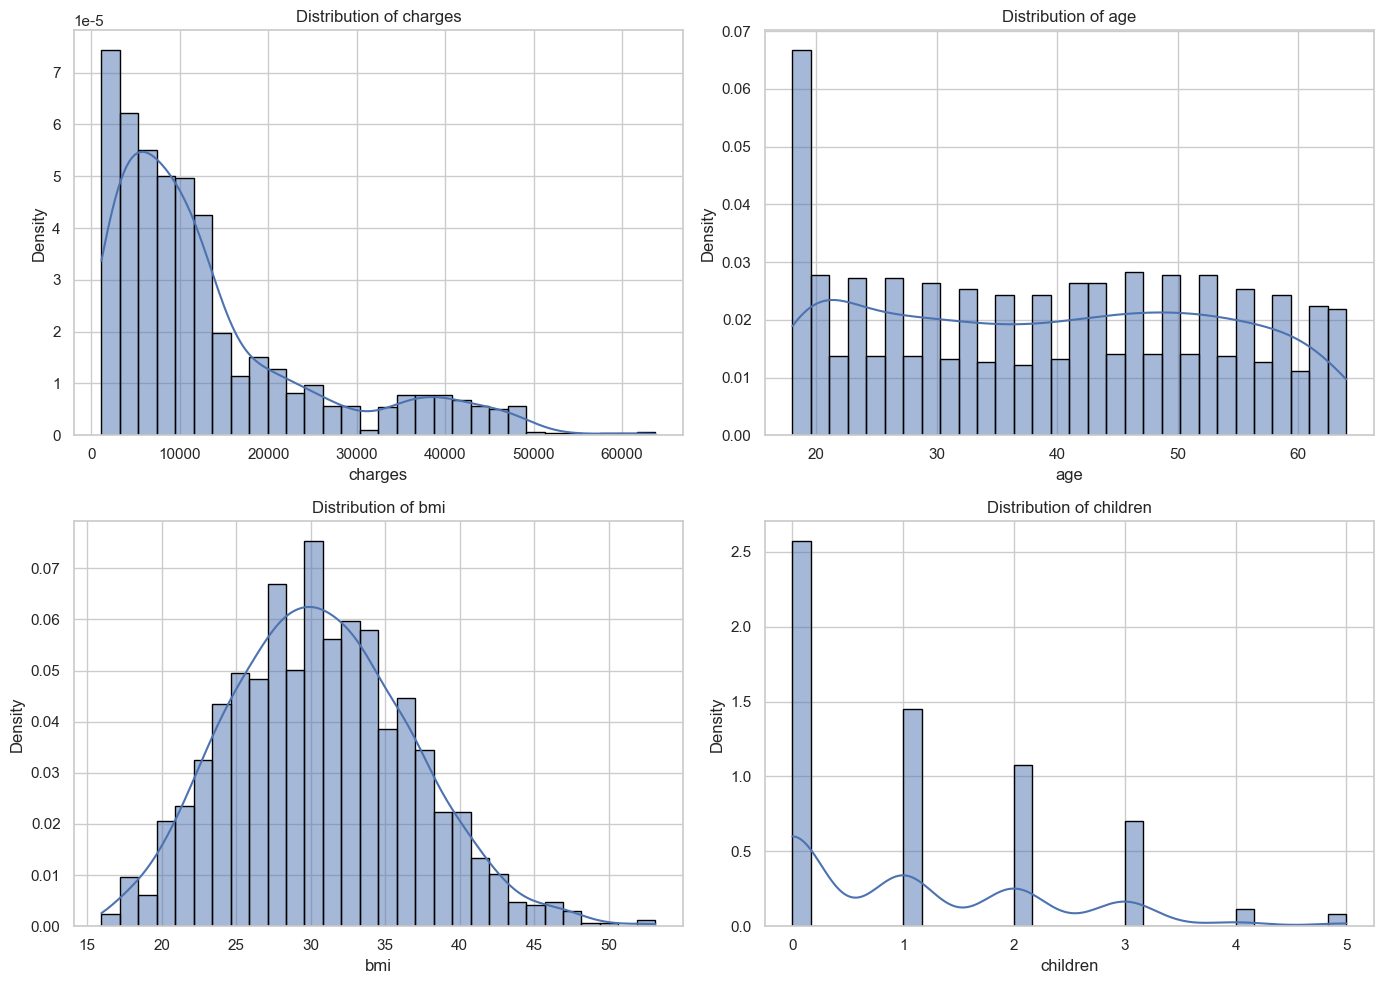

charges
강한 우측 편향
소수의 고액 청구가 평균을 크게 끌어올림


age
비교적 균등 분포


bmi
완만한 우측 편향
고BMI 구간에서 의료비 증가와 연결 가능
경계값 기반 이상치 점검은 필요
children
이산형
0~2에 집중



In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 스타일
sns.set(style="whitegrid")

cols = ['charges', 'age', 'bmi', 'children']

plt.figure(figsize=(14, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(
        data=origin,
        x=col,
        bins=30,
        kde=True,
        stat='density',
        edgecolor='black'
    )
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Density')

plt.tight_layout()
plt.show()
print(f"charges\n강한 우측 편향\n소수의 고액 청구가 평균을 크게 끌어올림")
print(f"\n\nage\n비교적 균등 분포")
print(f"\n\nbmi\n완만한 우측 편향\n고BMI 구간에서 의료비 증가와 연결 가능\n경계값 기반 이상치 점검은 필요")
print(f"children\n이산형\n0~2에 집중\n")

In [13]:
# BMI 구간 정의 (의학적으로 합리적인 기준)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# BMI 구간화
bmi_bins = [0, 18.5, 25, 30, 35, 100]
bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese I', 'Obese II+']

origin['bmi_group'] = pd.cut(
    origin['bmi'],
    bins=bmi_bins,
    labels=bmi_labels
)


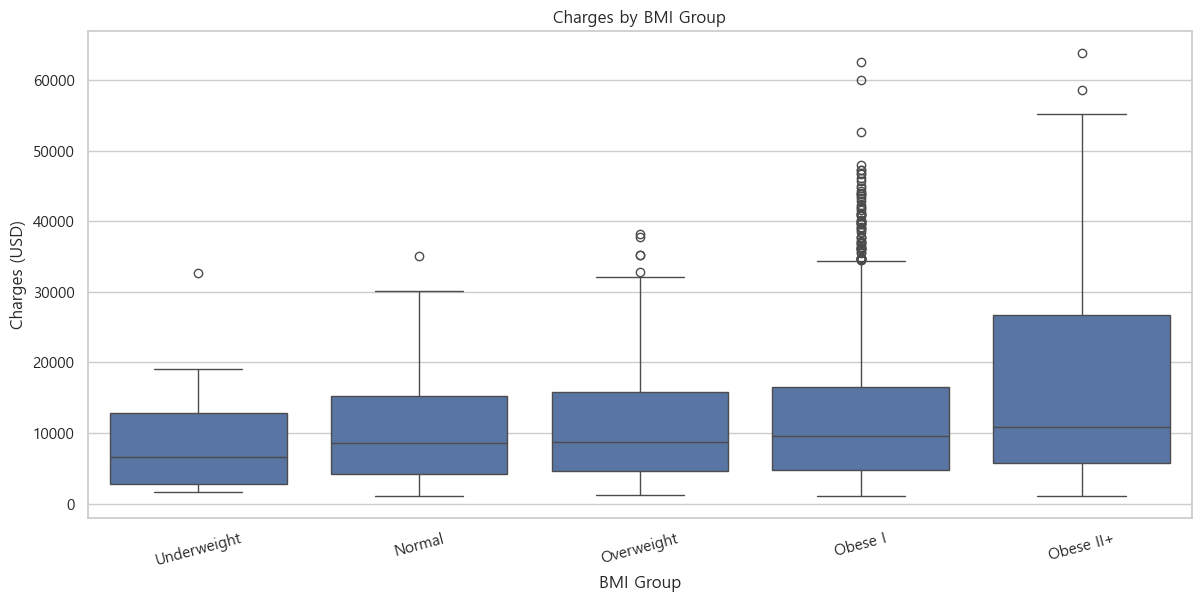

In [31]:
# BMI 구간별 charges Boxplot
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=origin,
    x='bmi_group',
    y='charges'
)

plt.title('Charges by BMI Group')
plt.xlabel('BMI Group')
plt.ylabel('Charges (USD)')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


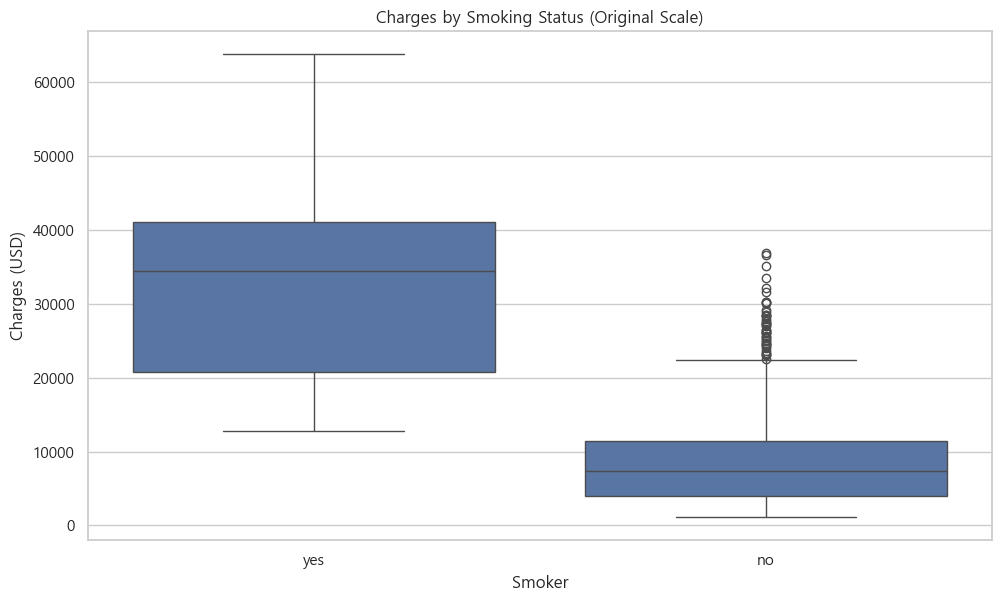

In [32]:
# 흡연자 vs 비흡연자 차이
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=origin,
    x='smoker',
    y='charges'
)

plt.title('Charges by Smoking Status (Original Scale)')
plt.xlabel('Smoker')
plt.ylabel('Charges (USD)')

plt.tight_layout()
plt.show()


In [36]:
origin.groupby('smoker')['charges'].describe()


,count,mean,std,min,25%,50%,75%,max
smoker,,,,,,,,
no,1064.0,8434.268298,5993.781819,1121.8739,3986.438700,7345.40530,11362.887050,36910.60803
yes,274.0,32050.231832,11541.547176,12829.4551,20826.244213,34456.34845,41019.207275,63770.42801


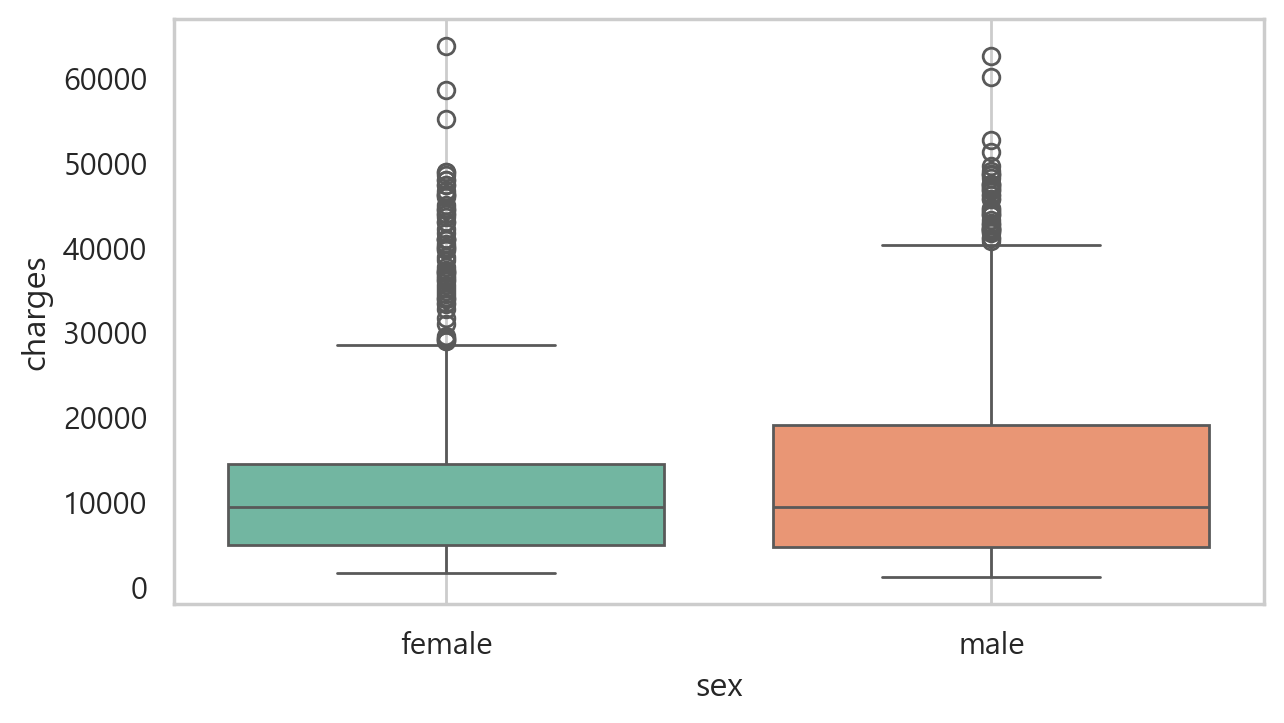

In [33]:
# 박스플롯
hs_plot.hs_boxplot(df = origin, xname="sex", yname="charges", palette = "Set2",  hue="sex")


In [38]:
origin.groupby('sex')['charges'].describe()

,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
female,662.0,12569.578844,11128.703801,1607.5101,4885.1587,9412.96250,14454.691825,63770.42801
male,676.0,13956.751178,12971.025915,1121.8739,4619.1340,9369.61575,18989.590250,62592.87309


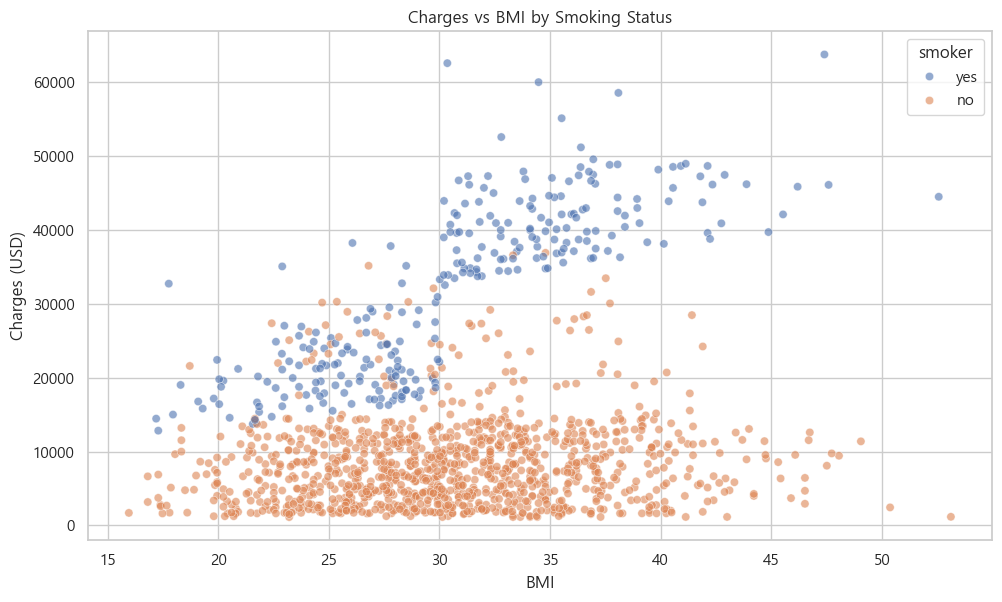

In [39]:
# BMI vs charges, 흡연 여부로 분리
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=origin,
    x='bmi',
    y='charges',
    hue='smoker',
    alpha=0.6
)

plt.title('Charges vs BMI by Smoking Status')
plt.xlabel('BMI')
plt.ylabel('Charges (USD)')
plt.tight_layout()
plt.show()


In [ ]:
width_px = 1280
height_px = 760
rows = 1
cols=1
figsize = (width_px /my_dpi, height_px/my_dpi)
fig, ax = plt.subplots(rows,cols,figsize=figsize, dpi=my_dpi)

# 그래프 그리기->seaborn 사용
sb.lineplot(data=⭐, x="⭐", hue="⭐", orient="v"),
        

plt.grid()
plt.tight_layout()
plt.show()``
plt.close()